In [1]:
import pandas as pd
from model_processor import ModelProcessor
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Date locale exportate din API DateModelare (agregat national 2016-2025) - vezi README.
source_df = pd.read_csv("venituri_total.csv")
indicatori_df = pd.read_csv("indicatori_total.csv")

In [3]:
source_df[source_df['Data'] >= '2025-01-01']

,Data,Valoare
106,2025-01-01T00:00:00,1.056539e+09
107,2025-02-01T00:00:00,9.513344e+08
108,2025-03-01T00:00:00,1.302514e+09
109,2025-04-01T00:00:00,8.860558e+08
110,2025-05-01T00:00:00,9.356843e+08
111,2025-06-01T00:00:00,9.118474e+08
112,2025-07-01T00:00:00,9.827400e+08
113,2025-08-01T00:00:00,8.334102e+08
114,2025-09-01T00:00:00,7.626279e+08
115,2025-10-01T00:00:00,9.072604e+08


### Facem join intre cele doua dataseturi

In [4]:
serie_df = pd.merge(
  source_df,
  indicatori_df.rename(columns={'Data': 'data_indicatori'}),
  how='left',
  left_on='Data',
  right_on='data_indicatori'
).drop(columns=['data_indicatori'])

In [5]:
serie_df = serie_df.rename(columns={'Valoare': 'Income'})

### Initializam clasa care proceseaza modelul

In [6]:
procesor = ModelProcessor(serie_df, 'Total Revenues (Income)', target_col='income')

### Rulam anliza asupra datelor

<Figure size 1600x800 with 0 Axes>

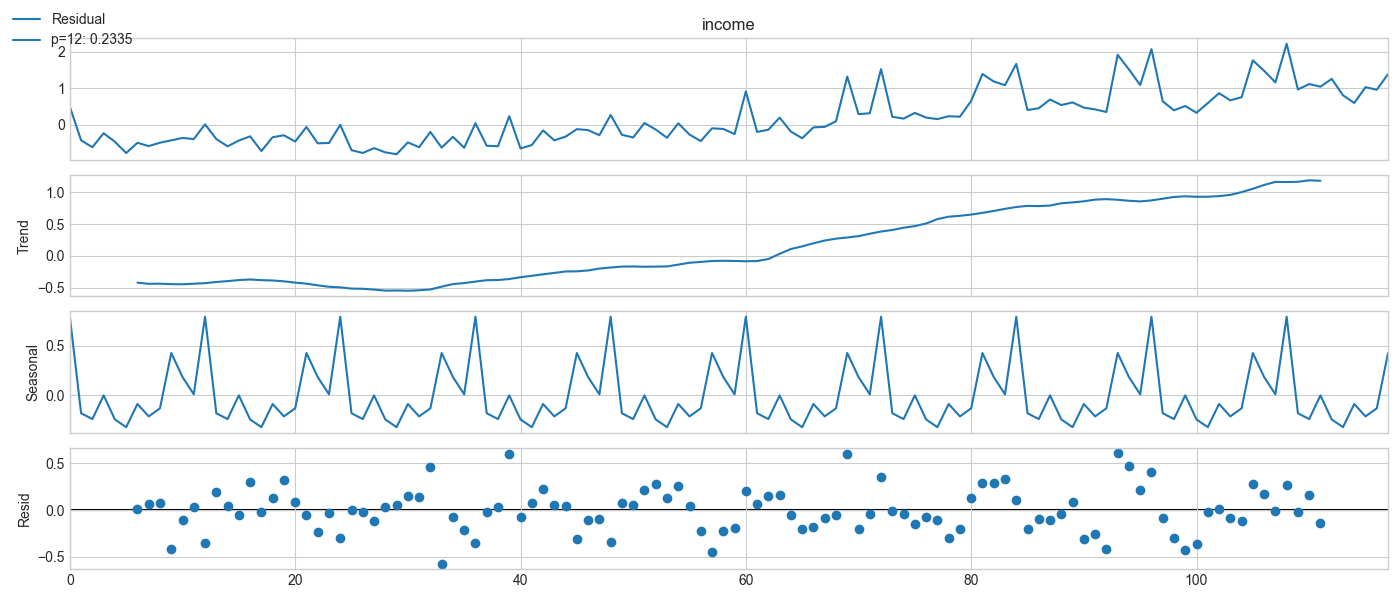

<Figure size 1000x400 with 0 Axes>

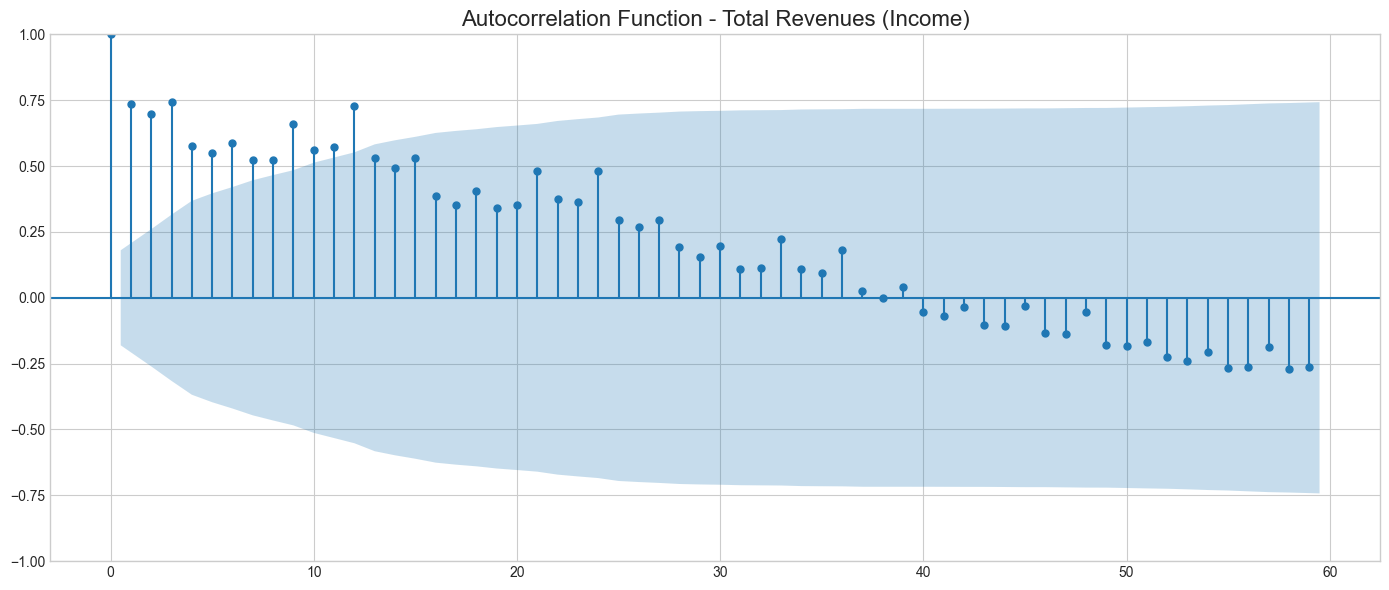

<Figure size 1000x400 with 0 Axes>

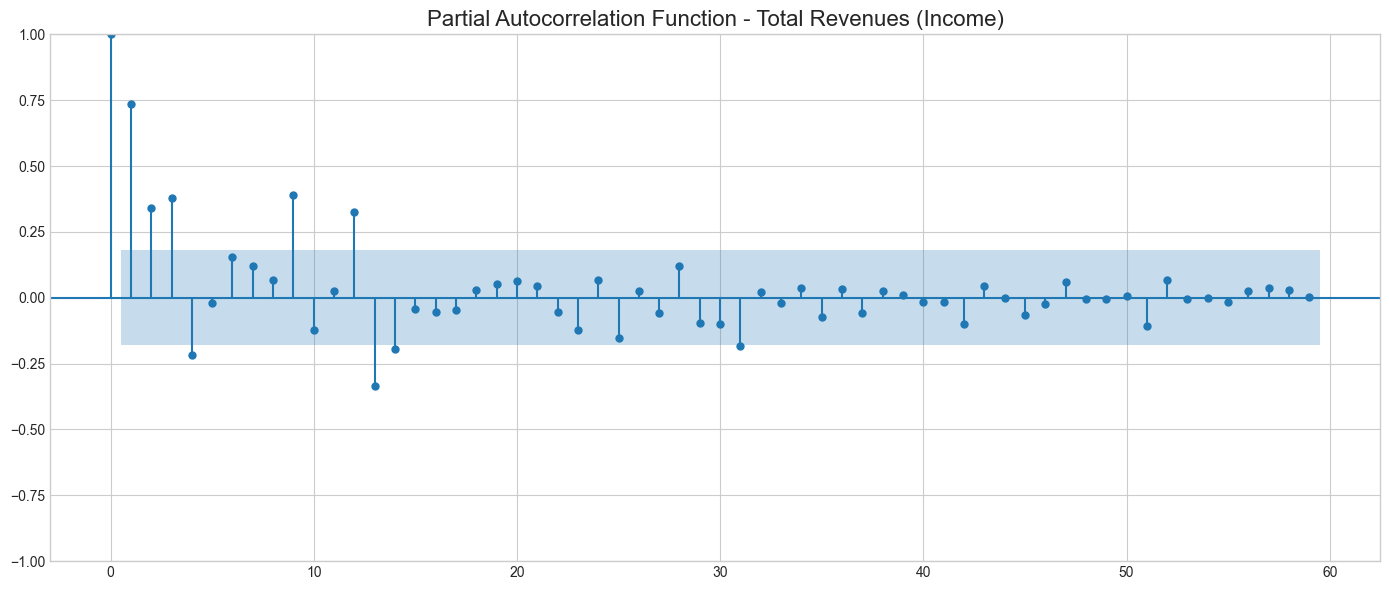

Optimal seasonality period: 12
Residual std dev: 0.2335
The largest ACF coefficient (excluding lag 0) is at lag 3: 0.743
The largest PACF coefficient (excluding lag 0) is at lag 57: 4.080
The series shows strong autocorrelation at the first lag (possible AR or MA process).
The series shows strong partial autocorrelation at the first lag (possible AR process).


In [7]:
procesor.analyze()

### Rulam toate modelele

In [8]:
from models import ToateModelele
procesor.run_all_models(ToateModelele())

Importing plotly failed. Interactive plots will not work.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


17:03:10 - cmdstanpy - INFO - Chain [1] start processing


17:03:10 - cmdstanpy - INFO - Chain [1] done processing


### Afisam rezultatele


UNIVARIATE
                          model         r2      rmse        mape
0                Univariate ETS   0.687598  0.271296   24.651247
1                Univariate TCN   0.647995  0.287979   26.600384
2            Univariate Prophet   0.572274  0.317446   32.817213
3             Univariate SARIMA   0.556347  0.323302   32.414549
4               Univariate LSTM   0.360895  0.388037   34.870880
5     Univariate Seasonal Naive   0.350071  0.391309   33.777158
6                Univariate GRU   0.247112  0.421165   38.851125
7  Univariate Linear Regression -10.903440  1.674645  167.289064


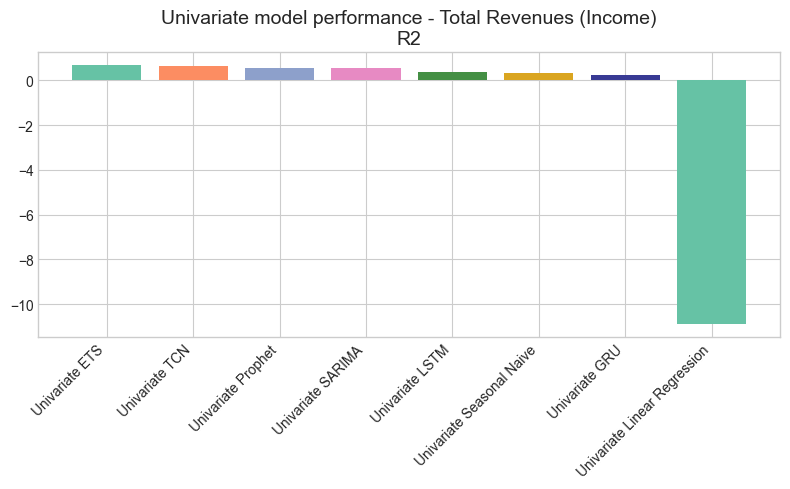

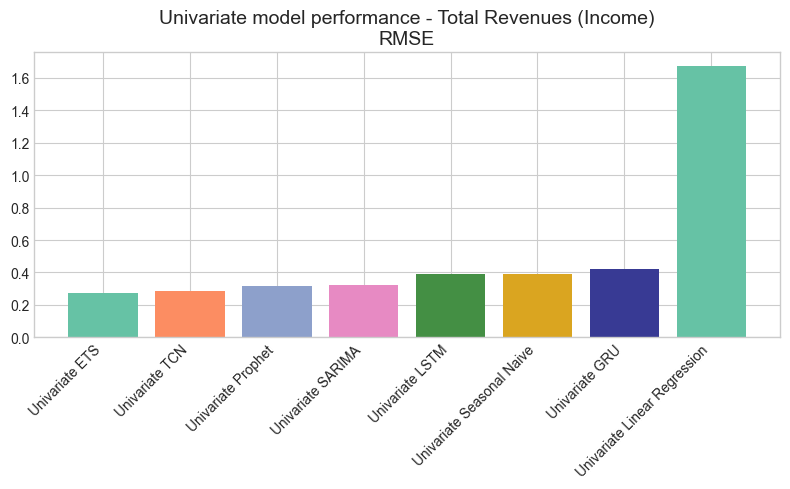

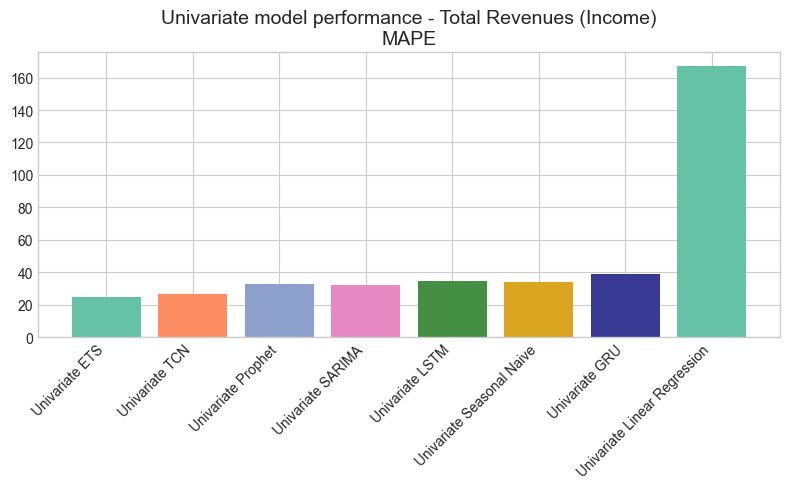


MULTIVARIATE
                            model        r2      rmse       mape
0                Multivariate VAR  0.257305  0.418304  43.217645
1             Multivariate SARIMA  0.065000  0.469345  41.712478
2  Multivariate Linear Regression  0.009386  0.483102  46.678815
3                Multivariate ECM  0.004180  0.484370  43.582264
4               Multivariate LSTM -0.074772  0.503205  36.781504
5                Multivariate GRU -0.098419  0.508710  35.656780
6                Multivariate TCN -0.105519  0.510352  60.026348


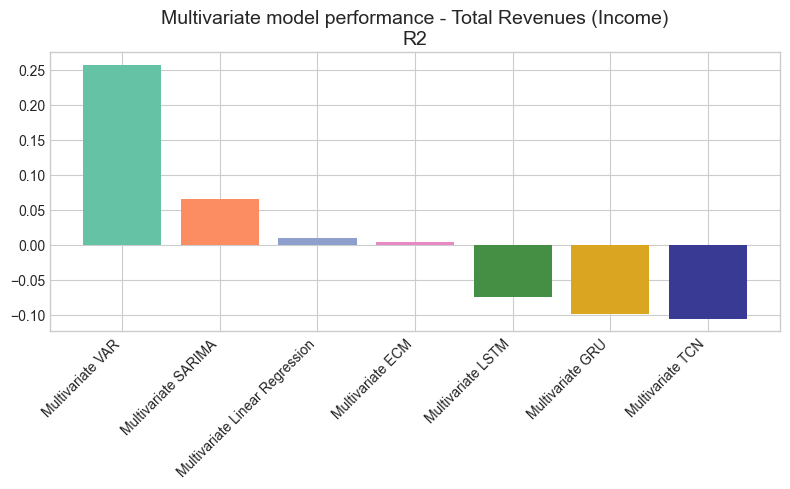

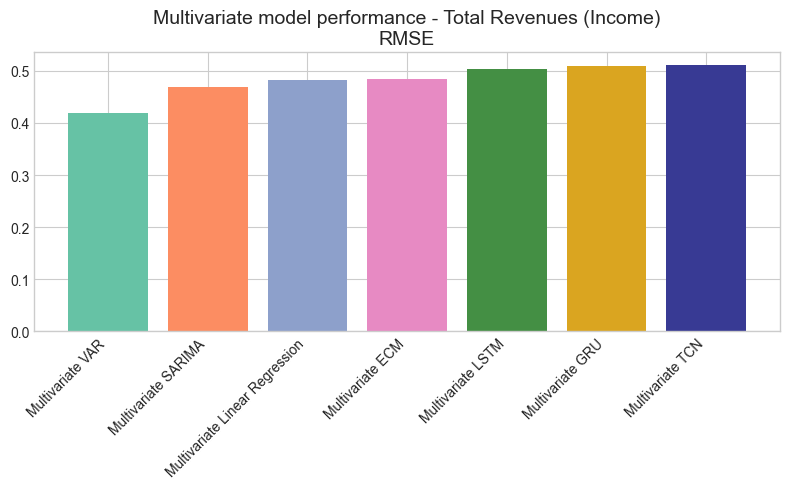

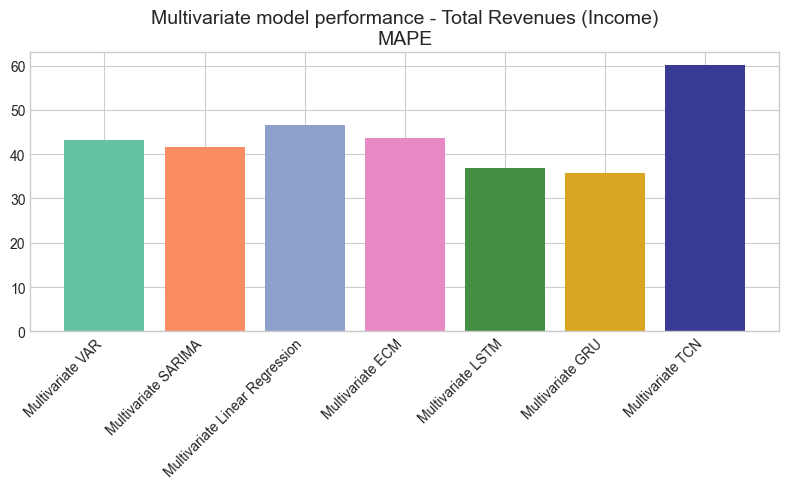

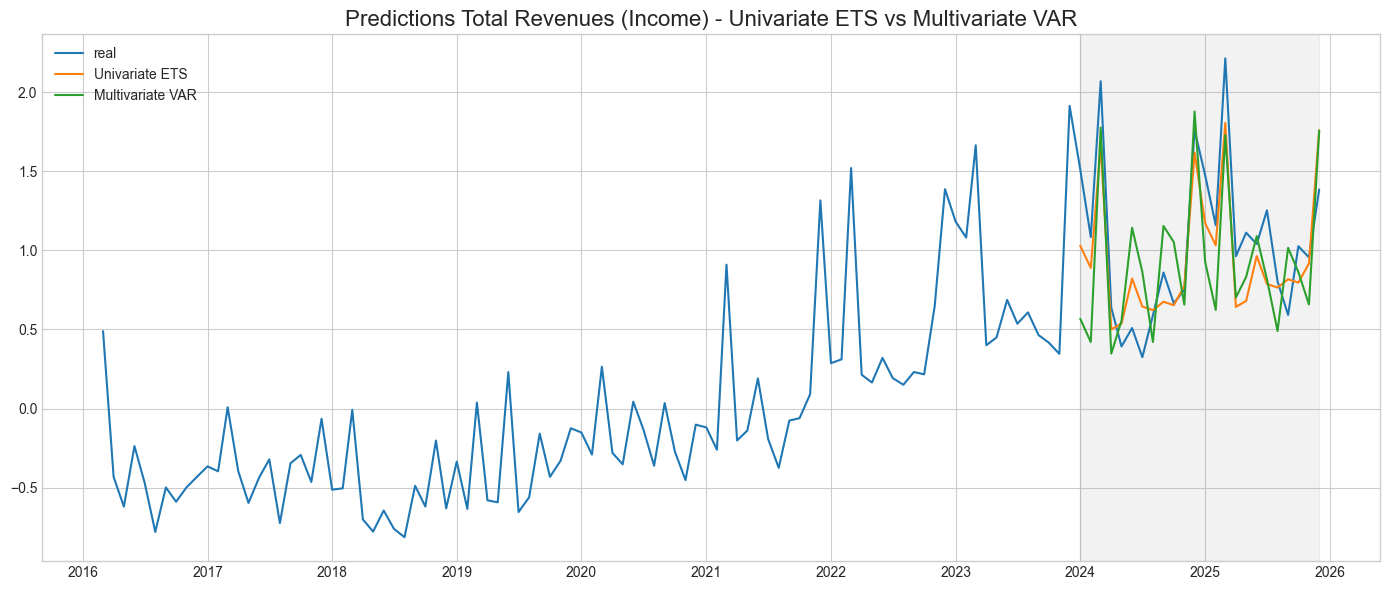

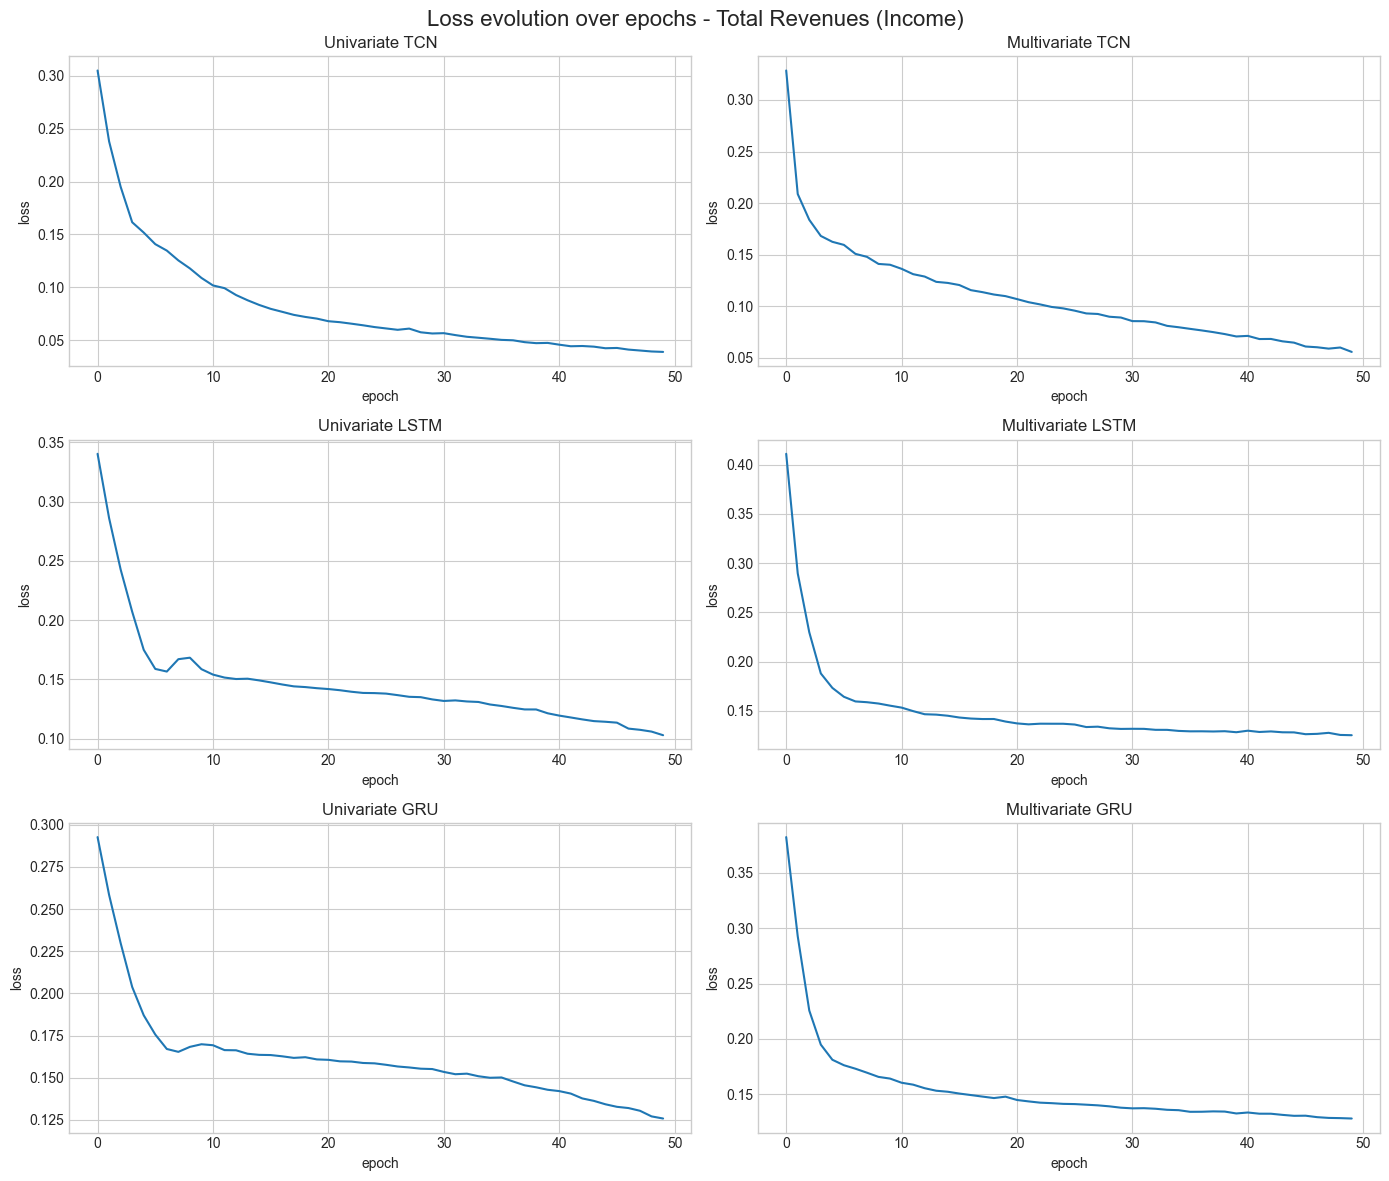

In [9]:
procesor.process_results()